## Cell 1: Load cleaned data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_df = pd.read_pickle('C:/Users/santh/battery-rul-project/data/processed/clean_battery_data.pkl')
clean_df = clean_df[clean_df['type'] == 'discharge'].reset_index(drop=True)
clean_df.head()

,battery,cycle_idx,type,voltage,current,temperature,capacity_Ah
0,B0005,1,discharge,"[4.191491807505295, 4.191004927950373, 4.12360...","[-0.004901589207462691, -0.002657367145453474,...","[24.330033885570543, 24.327385288702907, 24.34...",1.856487
1,B0005,3,discharge,"[4.189773213846608, 4.1891915832591025, 4.1250...","[2.125117981080765e-05, -0.0005661765024619325...","[24.697751935729325, 24.69005382346846, 24.701...",1.846327
2,B0005,5,discharge,"[4.188186735991303, 4.187545434539934, 4.12552...","[-0.0017540301662326099, -0.001778437560872837...","[24.734266163954402, 24.738310956683897, 24.75...",1.835349
3,B0005,7,discharge,"[4.188461118855572, 4.188003528970895, 4.12777...","[-0.0027750361294468047, -0.000832934037246042...","[24.65423646922845, 24.652950193336693, 24.665...",1.835263
4,B0005,9,discharge,"[4.188298524761055, 4.187708684562886, 4.12769...","[-0.007980866803888688, -0.0017310739133212117...","[24.524796959348127, 24.52086174427053, 24.534...",1.834646


## Cell 2: Calculate SOH (State of Health) 

In [2]:
# SOH = current cycle capacity / initial (rated) capacity of that battery
clean_df['initial_capacity'] = clean_df.groupby('battery')['capacity_Ah'].transform('first')
clean_df['SOH'] = clean_df['capacity_Ah'] / clean_df['initial_capacity']

clean_df[['battery', 'cycle_idx', 'capacity_Ah', 'SOH']].head(10)

,battery,cycle_idx,capacity_Ah,SOH
0,B0005,1,1.856487,1.000000
1,B0005,3,1.846327,0.994527
2,B0005,5,1.835349,0.988614
3,B0005,7,1.835263,0.988567
4,B0005,9,1.834646,0.988235
5,B0005,11,1.835662,0.988782
6,B0005,13,1.835146,0.988504
7,B0005,15,1.825757,0.983447
8,B0005,17,1.824774,0.982917
9,B0005,19,1.824613,0.982831


## Cell 3: Identify EOL (End of Life) cycle based on each battery

In [3]:
EOL_THRESHOLD = 0.70   # cycle where SOH reaches 70% = End of Life (industry-standard threshold)

eol_cycles = {}
for b in clean_df['battery'].unique():
    sub = clean_df[clean_df['battery'] == b].sort_values('cycle_idx')
    below = sub[sub['SOH'] <= EOL_THRESHOLD]
    eol_cycles[b] = below['cycle_idx'].iloc[0] if len(below) else sub['cycle_idx'].max()

print("EOL cycle per battery:", eol_cycles)

EOL cycle per battery: {'B0005': np.int64(590), 'B0006': np.int64(358), 'B0007': np.int64(612), 'B0018': np.int64(318)}


## Cell 4: Calculate RUL (Remaining Useful Life) 

In [4]:
def compute_rul(row):
    return max(eol_cycles[row['battery']] - row['cycle_idx'], 0)

clean_df['RUL'] = clean_df.apply(compute_rul, axis=1)
clean_df[['battery', 'cycle_idx', 'capacity_Ah', 'SOH', 'RUL']].head(10)

,battery,cycle_idx,capacity_Ah,SOH,RUL
0,B0005,1,1.856487,1.000000,589
1,B0005,3,1.846327,0.994527,587
2,B0005,5,1.835349,0.988614,585
3,B0005,7,1.835263,0.988567,583
4,B0005,9,1.834646,0.988235,581
5,B0005,11,1.835662,0.988782,579
6,B0005,13,1.835146,0.988504,577
7,B0005,15,1.825757,0.983447,575
8,B0005,17,1.824774,0.982917,573
9,B0005,19,1.824613,0.982831,571


## Cell 5: visualize sanity-check

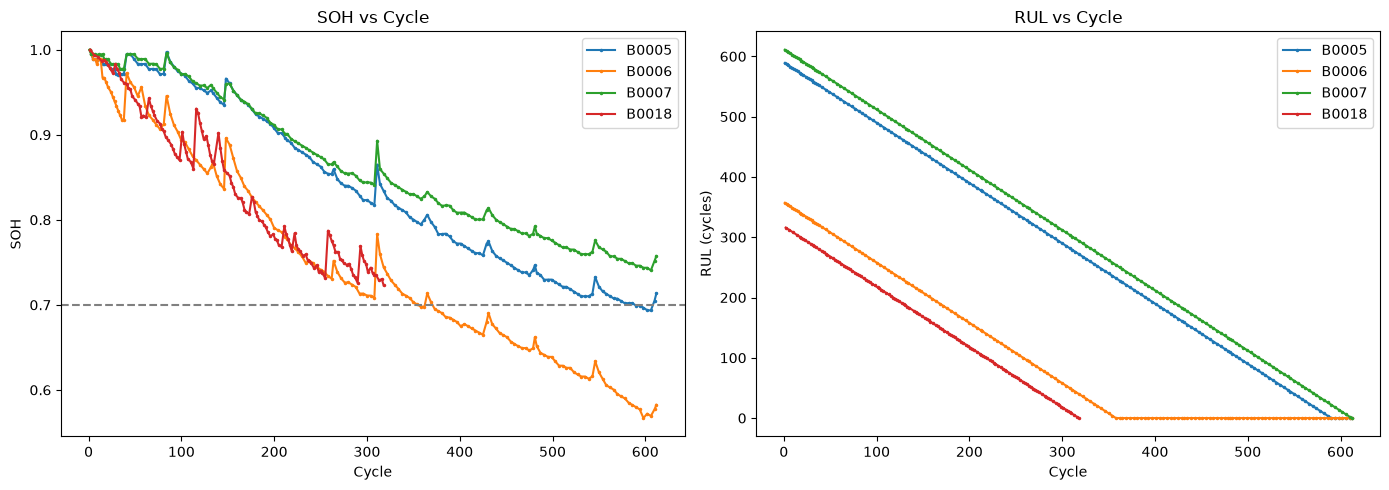

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for b in clean_df['battery'].unique():
    sub = clean_df[clean_df['battery'] == b]
    axes[0].plot(sub['cycle_idx'], sub['SOH'], label=b, marker='.', markersize=3)
    axes[1].plot(sub['cycle_idx'], sub['RUL'], label=b, marker='.', markersize=3)

axes[0].axhline(EOL_THRESHOLD, color='gray', linestyle='--')
axes[0].set_title('SOH vs Cycle'); axes[0].set_xlabel('Cycle'); axes[0].set_ylabel('SOH'); axes[0].legend()
axes[1].set_title('RUL vs Cycle'); axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('RUL (cycles)'); axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 6: save labeled dataset

In [6]:
clean_df.to_pickle('C:/Users/santh/battery-rul-project/data/processed/labeled_battery_data.pkl')
print("Saved labeled dataset:", clean_df.shape)

Saved labeled dataset: (636, 10)
